In [1]:
from namap_main import *
from src.pointing import *
P = ld.load_params('params_namap.par')

In [2]:
#------------------------------------------------------------------------------------------
num_frames, first_frame = P['num_frames'], P['first_frame']

#Lat and lst need to be implemented in strategy.py
lat, lst = P['lat'], P['lst']
#Also need to be implemented. 
telemetry = P['telemetry']

#So far, only 'RA and DEC' is implemented and working. 
if P['ctype'] == 'RA and DEC':
    coord1 = str('RA')
    coord2 = str('DEC')
    xystage = False
elif P['ctype'] == 'AZ and EL':
    coord1 = str('AZ')
    coord2 = str('EL')
    xystage = False
elif P['ctype'] == 'CROSS-EL and EL':
    coord1 = str('xEL')
    coord2 = str('EL')
    xystage = False
elif P['ctype'] == 'XY Stage':
    coord1 = str('X')
    coord2 = str('Y')
    xystage = True

filepath = P['hdf5_file']

btable = tb.Table.read(P['detector_table'], format='ascii.tab')
filtered = btable[btable['Frequency'] == P['frequency']]
kid_num = filtered['Name'] #(filtered['Name'][0],)

#load the table
dettable = ld.det_table(kid_num, P['detector_table']) 
det_off, noise_det, resp = dettable.loadtable()

#Cleaning data parameters
highpassfreq = P['highpassfreq']
polynomialorder = P['polynomialorder']
despike_bool = P['despike']
sigma,prominence = P['sigma'],P['prominence']
#So far, the cleaning parameters are set such as no cleaning is applied. 
#Because the simulated TODS dont have noise or noise peaks. 

#Beam convolution parameters
convolution, std = P['gaussian_convolution'], P['std'] 
#-------------------------------------------------------------------------------------------------------------------------
#Load the data
dataload = ld.data_value(filepath, kid_num, filepath, coord1, coord2, lst, lat, first_frame, num_frames, xystage, telemetry)
det_data, coord1_data, coord2_data, lst, lat, spf_data, spf_coord, lat_spf, all_coord1, all_coord2 = dataload.values()
#--------------------
#Synchronize the data
#Needs to be modify , nothing to synchronize so far. 
'''
zoomsyncdata = ld.frame_zoom_sync(filepath, det_data, spf_data, spf_data, coord1_data, coord2_data, spf_coord, spf_coord, 
                                    first_frame, num_frames+first_frame,  lst,lat,lat_spf, lat_spf, P['time_offset'], xystage,)
timemap, detslice, coord1slice, coord2slice, lstslice, latslice = zoomsyncdata.sync_data()
'''
coord1slice = coord1_data
coord2slice = coord2_data
lstslice = lst
latslice = lat
detslice = det_data
cleaned_data = detslice        
#Offset with respect to star cameras in xEL and EL
xsc_offset = (P['xsc_offset'],P['det_offset']) #needs to be tested with real offsets. 

In [3]:
#corr = pt.apply_offset(coord1slice, coord2slice, P['ctype'], xsc_offset, det_offset = det_off, lst = lstslice, lat = latslice)
#coord1slice, coord2slice = corr.correction()

#--------------------------------------------------
coord1 = coord1slice
coord2 = coord2slice
det_offset = det_off
ctype = P['ctype']

conv2azel = utils(coord1/15, coord2, lst, lat) #hour, deg, hour, deg
az, el = conv2azel.radec2azel()
xEL = np.degrees(np.radians(az)*np.cos(np.radians(el)))

ra_corrected = np.zeros((int(np.size(det_offset)/2), len(az)))
dec_corrected = np.zeros((int(np.size(det_offset)/2), len(az)))

ra_deux = []
dec_deux = []

for i in range(int(np.size(det_offset)/2)):
    
    xEL_corrected_temp = xEL + det_offset[i,0] #xEL_offset
    EL_corrected_temp = el + det_offset[i,1] #EL_offset
    AZ_corrected_temp = np.degrees(np.radians(xEL_corrected_temp)/np.cos(np.radians(el)))
    conv2radec = utils(AZ_corrected_temp, EL_corrected_temp, lst, lat) #deg, deg, hour, deg
    ra_corrected[i,:], dec_corrected[i,:] = conv2radec.azel2radec()
    

    #-----------------------------------------------------------------------------------------
    sin_dec_namap = sin_el*sin_lat+cos_lat*cos_el*cos_az
    dec_namap = np.arcsin(sin_dec_namap)
    cos_dec_namap = np.cos(dec_namap)
    hour_angle = np.arccos((sin_el-sin_lat*sin_dec_namap)/(cos_lat*cos_dec_namap))
    index, = np.where(sin_az > 0)
    hour_angle[index] =  - hour_angle[index]
    ra_namap = HA*15 - np.degrees(hour_angle) #self.ha2ra(hour_angle/15.)*15.
    index, = np.where(ra_namap<0)
    #ra_namap[index]+=360
    path_namap = np.vstack((ra_namap,np.degrees(dec_namap))).T
    #-----------------------------------------------------------------------------------------




/home/mvancuyck/Desktop/TIM_analysis/namap/src/mapmaker.py:334: RuntimeWarning: invalid value encountered in divide
  hist /= norm


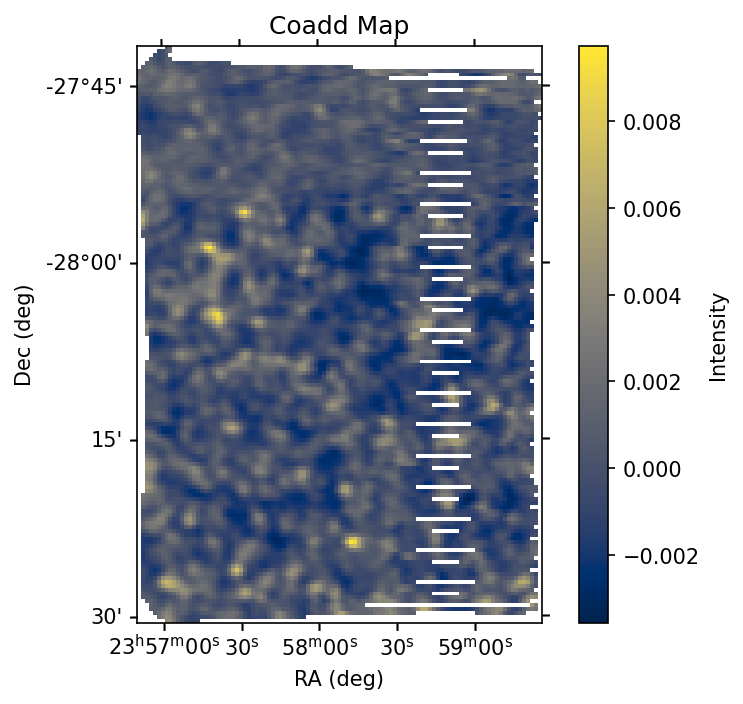

In [4]:
parallactic =  np.zeros_like(coord1slice) 
maps = mp.maps(P['ctype'], P['crpix'], P['cdelt'], P['crval'], P['pixnum'], cleaned_data, ra_corrected, dec_corrected, convolution, std, 
                coadd=P['coadd'], noise=noise_det, telcoord = P['telescope_coordinate'], parang=parallactic)
maps.wcs_proj()
map_values = maps.map2d()
maps.map_plot(data_maps = map_values, kid_num=kid_num)


/home/mvancuyck/Desktop/TIM_analysis/namap/src/mapmaker.py:334: RuntimeWarning: invalid value encountered in divide
  hist /= norm


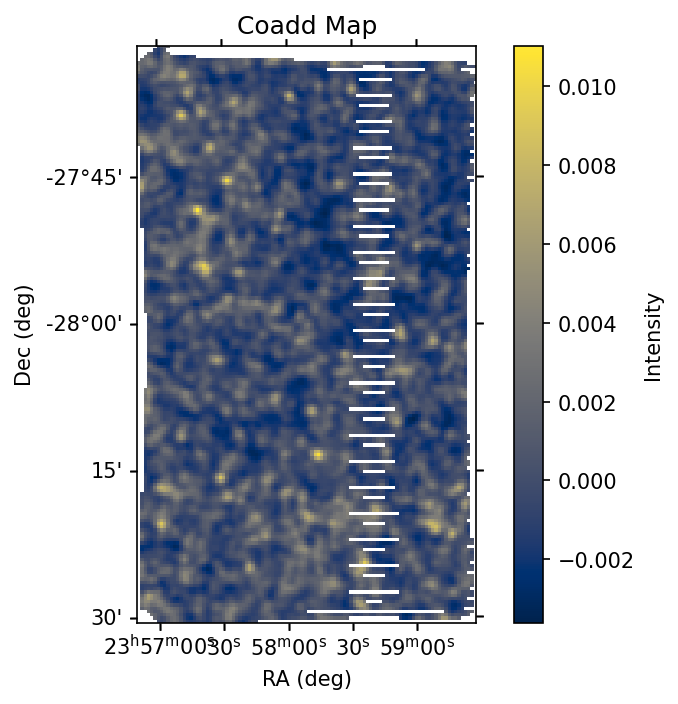

In [5]:
parallactic =  np.zeros_like(coord1slice) 
maps = mp.maps(P['ctype'], P['crpix'], P['cdelt'], P['crval'], P['pixnum'], cleaned_data, all_coord1, all_coord2, convolution, std, 
                coadd=P['coadd'], noise=noise_det, telcoord = P['telescope_coordinate'], parang=parallactic)
maps.wcs_proj()
map_values = maps.map2d()
maps.map_plot(data_maps = map_values, kid_num=kid_num)

In [ ]:
# Function to convert AZ and EL to RA and DEC
sin_el = np.sin(np.radians(el_convert))
sin_az = np.sin(np.radians(az_convert))
cos_el = np.cos(np.radians(el_convert))
cos_az = np.cos(np.radians(az_convert))


#axs[1,0].plot(path_namap[:,0], path_namap[:,1], c='b')
#axs[1,0].set_xlabel('RA [deg]');axs[1,0].set_ylabel('Dec [deg]')